# 1. Exploratory Data Analysis & Setup

This notebook performs three functions:
1. **Exploratory Data Analysis (EDA)** of both datasets used in the project.
2. **Evaluation metrics:** definition, explanation, and sanity check.
3. **One-shot example selection** for inference baselines.

The EDA results inform preprocessing decisions and hyperparameter choices in the model-specific notebooks (`2_smolvlm.ipynb`, `3_qwen3vl.ipynb`). Metrics are used by both model notebooks via the shared module `metrics.py`.

This notebook explores the two datasets used for Supervised Fine-Tuning: `linxy/LaTeX_OCR` (primary, with train/val/test splits) and `deepcopy/MathWriting-human` (supplementary, train split only). The goals are:

- understand the structure, quality, and statistical properties of each dataset;
- assess their compatibility for combined training;
- prepare a representative subsample of MathWriting-human.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 7.6 MB/s eta 0:00:00


In [ ]:
import os
import sys
import random
from hashlib import md5

from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Dataset, load_dataset
from tqdm import tqdm

# Ensure shared modules are importable
if os.path.exists("metrics.py"):
    sys.path.insert(0, ".")
else:
    sys.path.insert(0, "/content/drive/MyDrive/latex_ocr_project")
from metrics import compute_metrics, normalize_latex

In [ ]:
MW_SUBSAMPLE_SIZE = 5000
RANDOM_STATE = 42
SEED = 42

### 1.1. linxy/LaTeX_OCR


The primary dataset, [linxy/LaTeX_OCR](https://huggingface.co/datasets/linxy/LaTeX_OCR/viewer/human_handwrite), contains handwritten mathematical formulas with corresponding LaTeX annotations. This is the main dataset: it provides the training, validation, and test splits used throughout the project. Evaluation is always performed on its test split (70 examples).


#### 1.1.1. Dataset Overview


In [ ]:
dataset = load_dataset("linxy/LaTeX_OCR", name="human_handwrite")

README.md:   0%|          | 0.00/5.73k [00:00<?, ?B/s]

human_handwrite/train-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 16.2MB            

human_handwrite/train-00000-of-00001.par(…): downloading bytes:           |  0.00B            

human_handwrite/validation-00000-of-0000(…): reconstructing file:   0%|          |  0.00B /  961kB            

human_handwrite/validation-00000-of-0000(…): downloading bytes:           |  0.00B            

human_handwrite/test-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B /  906kB            

human_handwrite/test-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/68 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70 [00:00<?, ? examples/s]

In [ ]:
dataset


DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 68
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 70
    })
})

The dataset contains 1,200 training, 68 validation, and 70 test examples (≈90/5/5 split). Each example includes an image and its LaTeX text. Given the relatively modest size of the training set, we are mindful of the risk of overfitting — a risk that is exacerbated by duplicated examples. As Lee et al. (2022) show, duplicates increase memorization and degrade generalization, making deduplication particularly important in our setting.

Before proceeding with quality checks, let us first examine the actual content of a single example from each split to understand the data format. We display the image type, mode, size, and a preview of the corresponding LaTeX text.


In [ ]:
def examine_split(dataset, split_name="train"):
    if split_name not in dataset:
        print(f"Split '{split_name}' not found. Available: {list(dataset.keys())}")
        return
    example = dataset[split_name][0]
    print(f"\n{split_name.upper()} split:")
    for key, value in example.items():
        if key == "image":
            print(f"  {key}: {type(value).__name__}, size={value.size}, mode={value.mode}")
        else:
            print(f"  {key}: {type(value).__name__} = {repr(value)[:100]}")
    print(f"Total: {len(dataset[split_name])} examples")

In [ ]:
for split in ["train", "validation", "test"]:
    examine_split(dataset, split)



TRAIN split:
  image: PngImageFile, size=(515, 71), mode=RGBA
  text: str = 'z _ { 1 } = r _ { 1 } ( \\cos \\theta _ { 1 } + i \\sin \\theta _ { 1 } )'
Total: 1200 examples

VALIDATION split:
  image: PngImageFile, size=(515, 134), mode=RGBA
  text: str = '\\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ^ { 2 } }'
Total: 68 examples

TEST split:
  image: PngImageFile, size=(515, 213), mode=RGBA
  text: str = '\\sqrt { b ^ { 2 } - 4 a c }'
Total: 70 examples


We observe that all images are PNG files with RGBA mode and varying dimensions. The text field contains tokenized LaTeX strings with spaces between tokens. This format is standard for sequence-to-sequence models. Now, having confirmed the data structure, we proceed to check for missing values and duplicates.


We check for pixel-level duplicate images (identical pixel data) to detect data collection artifacts where the same image file was included multiple times. Deduplication of training data has been shown to improve model quality and reduce memorization (Lee et al., 2022).

Duplicate groups: 36, total duplicate images: 72
  Within-split: 30  |  Cross-split: 6


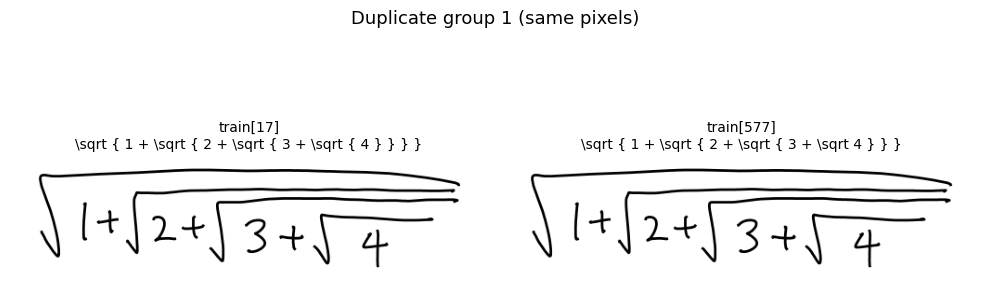

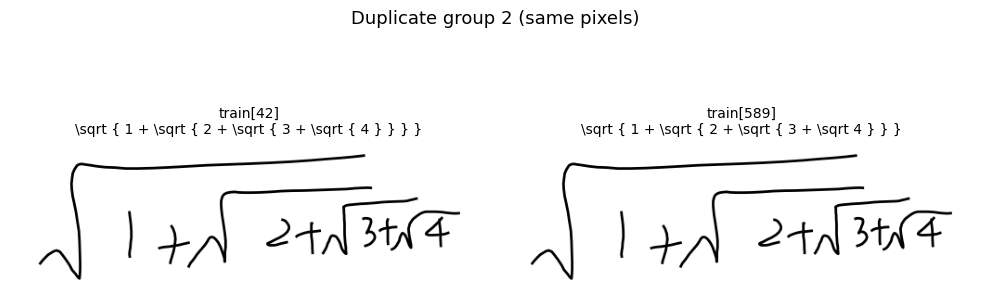

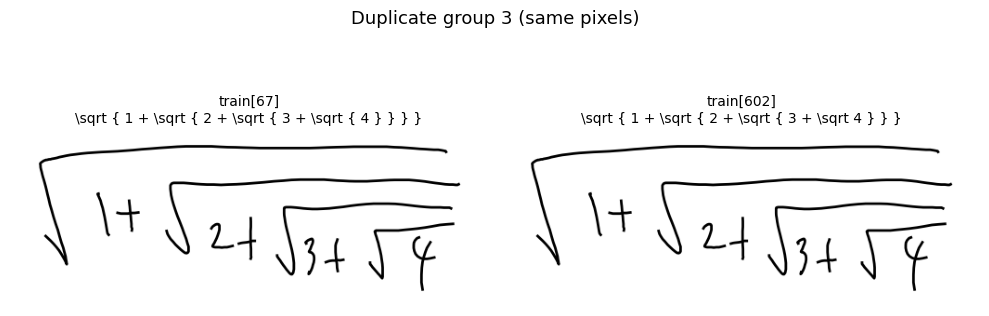

In [ ]:
# Detect and inspect pixel-level duplicate images
hash_map = {}  # hash -> [(split, idx), ...]
for split_name in dataset.keys():
    for idx, ex in enumerate(dataset[split_name]):
        h = md5(ex["image"].tobytes()).hexdigest()
        hash_map.setdefault(h, []).append((split_name, idx))

dup_groups = {h: locs for h, locs in hash_map.items() if len(locs) > 1}
print(f"Duplicate groups: {len(dup_groups)}, "
      f"total duplicate images: {sum(len(v) for v in dup_groups.values())}")

# Split distribution
cross_split = sum(1 for locs in dup_groups.values()
                  if len(set(s for s, _ in locs)) > 1)
within_split = len(dup_groups) - cross_split
print(f"  Within-split: {within_split}  |  Cross-split: {cross_split}")

# Visual inspection (up to 3 groups)
for i, (h, locs) in enumerate(dup_groups.items()):
    if i >= 3:
        break
    n = len(locs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (split, idx) in zip(axes, locs):
        ex = dataset[split][idx]
        ax.imshow(ex["image"])
        ax.set_title(f"{split}[{idx}]\n{ex['text']}", fontsize=10)
        ax.axis("off")
    fig.suptitle(f"Duplicate group {i+1} (same pixels)", fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
# Check if duplicate images have consistent or conflicting text labels
diff_text_count = 0
same_text_count = 0
for h, locs in dup_groups.items():
    texts = [dataset[split][idx]["text"] for split, idx in locs]
    if len(set(texts)) > 1:
        diff_text_count += 1
    else:
        same_text_count += 1

print(f"  Same-text duplicates: {same_text_count}")
print(f"  Different-text duplicates: {diff_text_count}")

  Same-text duplicates: 0
  Different-text duplicates: 36


In [ ]:
# For each group of duplicates, we display all texts
for i, (h, locs) in enumerate(dup_groups.items()):

    print(f"\n{'='*60}")
    print(f"Duplicate group {i+1} (hash: {h[:16]}...)")
    print(f"  Number of copies: {len(locs)}")
    print(f"  Locations: {locs}")
    print(f"  {'─'*50}")

    for j, (split, idx) in enumerate(locs):
        ex = dataset[split][idx]
        print(f"  [{split}][{idx}] text: {ex['text']}")

    print(f"{'='*60}")


Duplicate group 1 (hash: 4c56f294ae7731ce...)
  Number of copies: 2
  Locations: [('train', 17), ('train', 577)]
  ──────────────────────────────────────────────────
  [train][17] text: \sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt { 4 } } } }
  [train][577] text: \sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt 4 } } }

Duplicate group 2 (hash: d1fdca84a7d1ee9b...)
  Number of copies: 2
  Locations: [('train', 42), ('train', 589)]
  ──────────────────────────────────────────────────
  [train][42] text: \sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt { 4 } } } }
  [train][589] text: \sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt 4 } } }

Duplicate group 3 (hash: 3ce17b9d02ac37af...)
  Number of copies: 2
  Locations: [('train', 67), ('train', 602)]
  ──────────────────────────────────────────────────
  [train][67] text: \sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt { 4 } } } }
  [train][602] text: \sqrt { 1 + \sqrt { 2 + \sqrt { 3 + \sqrt 4 } } }

Duplicate group 4 (hash: 15fd4d1c7ef53424...)
  Number of copie

In [ ]:
# Remove duplicates from train
test_val_hashes = {h for h, locs in hash_map.items()
                   if any(s in ("test", "validation") for s, _ in locs)}

seen_hashes = set()
keep_indices = []
removed_cross = removed_within = 0

for idx, ex in enumerate(dataset["train"]):
    h = md5(ex["image"].tobytes()).hexdigest()
    if h in seen_hashes:
        removed_within += 1
        continue
    if h in test_val_hashes:
        removed_cross += 1
        continue
    seen_hashes.add(h)
    keep_indices.append(idx)

original_size = len(dataset["train"])
dataset["train"] = dataset["train"].select(keep_indices)
print(f"Train: {len(dataset['train'])} (was {original_size}, "
      f"removed {removed_within} within-dup + {removed_cross} cross-leak)")

Train: 1164 (was 1200, removed 30 within-dup + 6 cross-leak)


Duplicate groups were classified as within-split (same image repeated inside one split) or cross-split (same image appearing in multiple splits). All 36 duplicate groups had different but semantically equivalent LaTeX annotations (e.g., `\sqrt 4` vs `\sqrt { 4 }`, `\frac 1 { x }` vs `\frac { 1 } { x }`). All pixel-level duplicates were removed from the training set. Within-train duplicates add no new information and, in cases where annotations differ, introduce label noise that can confuse the model. Cross-split duplicates constitute data leakage that would inflate evaluation metrics and compromise the reliability of model assessment (Orji et al., 2023; Lee et al., 2022). Test and validation remain unchanged to preserve the original 70-example test set.


In [ ]:
results = []

for split_name in dataset.keys():
    data = dataset[split_name]
    texts = [ex["text"] for ex in data]

    results.append({
        "Split": split_name,
        "Examples": len(data),
        "Missing text": sum(1 for t in texts if not t),
        "Empty images": sum(1 for ex in data if ex['image'].size[0] == 0 or ex['image'].size[1] == 0),
        "Duplicate text": len(texts) - len(set(texts))
    })

pd.DataFrame(results)

,Split,Examples,Missing text,Empty images,Duplicate text
0,train,1164,0,0,873
1,validation,68,0,0,42
2,test,70,0,0,47


No missing values or empty images were found. However, duplicate texts are present in all splits — most notably in training. This indicates multiple handwritten versions of the same formula. Pixel-level image duplicates were detected and removed from the training set (see above).


We will examine one example with the highest duplication frequency in the next cell.


Text: x _ { x } ^ { x } + y _ { y } ^ { y } + z _ { z } ^ { z } - x - y - z...
Occurs 31 times


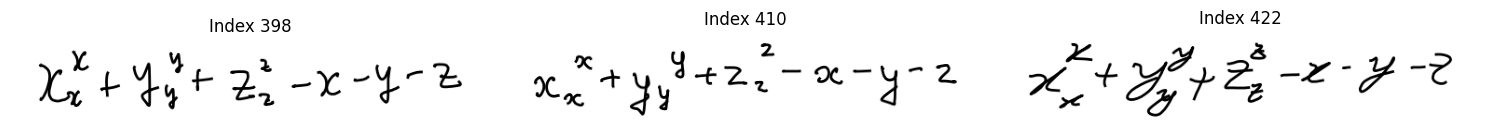

In [ ]:
# Find the most frequent duplicate text
text_counts = Counter(ex["text"] for ex in dataset["train"])
most_common_text = text_counts.most_common(1)[0][0]

indices = [i for i, ex in enumerate(dataset["train"]) if ex["text"] == most_common_text]

print(f"Text: {most_common_text}...")
print(f"Occurs {len(indices)} times")

n_show = min(3, len(indices))

fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4))

if n_show == 1:
    axes = [axes]

for ax, idx in zip(axes, indices[:n_show]):
    ex = dataset["train"][idx]
    ax.imshow(ex["image"])
    ax.set_title(f"Index {idx}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

The text duplicates observed within each split appear to be intentional: the same LaTeX formula is written in different handwriting styles. This diversity is beneficial for generalization and reducing overfitting. Pixel-level image duplicates, on the other hand, are data collection artifacts and were removed from the training set (see above).


In [ ]:
# Check overlaps between splits
train_texts = set(ex["text"] for ex in dataset["train"])
val_texts = set(ex["text"] for ex in dataset["validation"])
test_texts = set(ex["text"] for ex in dataset["test"])

print(f"Train & Validation: {len(train_texts & val_texts)} common texts")
print(f"Train & Test: {len(train_texts & test_texts)} common texts")
print(f"Validation & Test: {len(val_texts & test_texts)} common texts")

# Texts that appear in ALL three splits
common_all = train_texts & val_texts & test_texts
print(f"All three splits: {len(common_all)} common texts")

Train & Validation: 23 common texts
Train & Test: 23 common texts
Validation & Test: 23 common texts
All three splits: 23 common texts


We also check for overlaps between splits, as overlapping texts could potentially lead to data leakage and biased evaluation. The results show that 23 unique texts are shared across all three splits — training, validation, and test. To better understand the nature of these overlaps, we examine one example visually across the three splits.


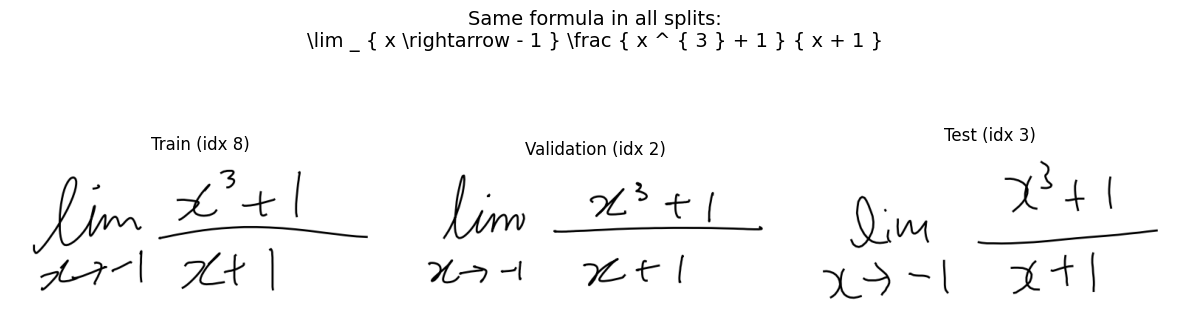

In [ ]:
# Take one example from common texts
common_list = list(common_all)
example_text = common_list[0]

train_idx = [i for i, ex in enumerate(dataset["train"]) if ex["text"] == example_text][0]
val_idx = [i for i, ex in enumerate(dataset["validation"]) if ex["text"] == example_text][0]
test_idx = [i for i, ex in enumerate(dataset["test"]) if ex["text"] == example_text][0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

ex_train = dataset["train"][train_idx]
axes[0].imshow(ex_train["image"])
axes[0].set_title(f"Train (idx {train_idx})", fontsize=12)
axes[0].axis("off")

ex_val = dataset["validation"][val_idx]
axes[1].imshow(ex_val["image"])
axes[1].set_title(f"Validation (idx {val_idx})", fontsize=12)
axes[1].axis("off")

ex_test = dataset["test"][test_idx]
axes[2].imshow(ex_test["image"])
axes[2].set_title(f"Test (idx {test_idx})", fontsize=12)
axes[2].axis("off")

plt.suptitle(f"Same formula in all splits:\n{example_text}", fontsize=14)
plt.tight_layout()
plt.show()

The visual inspection confirms that these 23 overlapping texts correspond to different handwriting styles of the same formulas. Preserving this diversity is more beneficial for generalization than removing them, especially given the already small size of the dataset.

Next, we visualize a few examples from each split to get a better sense of the data.


In [ ]:
def show_examples(dataset, split_name="train", n=6, cols=3, figsize=(30, 5)):
    if split_name not in dataset:
        print(f"\nSplit '{split_name}' not found. Available: {list(dataset.keys())}")
        return

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for i in range(n):
        ex = dataset[split_name][i]
        axes[i].imshow(ex["image"])
        axes[i].set_title(f"Example {i}\n\n{ex['text'][:100]}\n", fontsize=14)
        axes[i].axis("off")

    # Hide unused subplots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # Add main title (split name)
    fig.suptitle(f"Dataset: {split_name.upper()} split\n", fontsize=18, fontweight='bold')

    plt.tight_layout()
    plt.show()

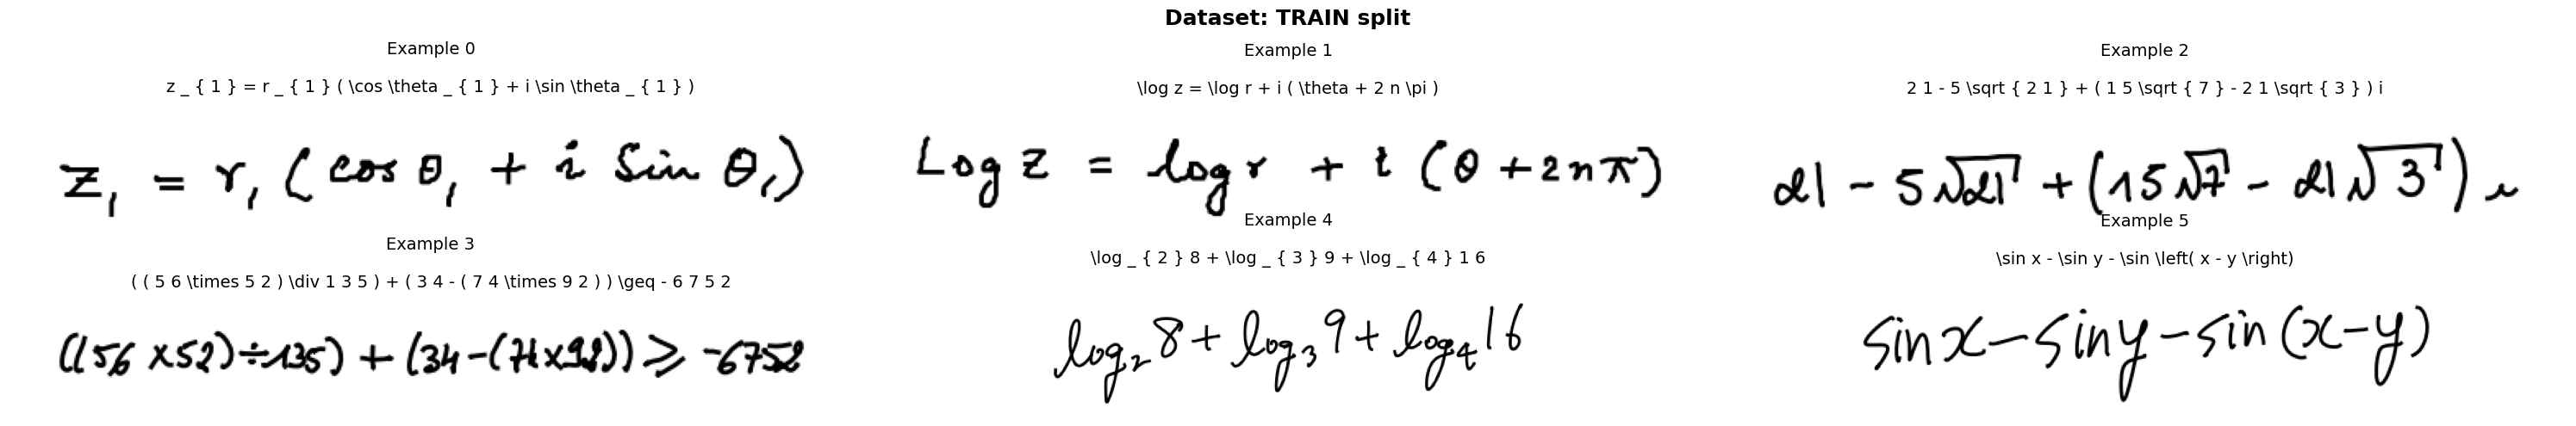

In [ ]:
show_examples(dataset, "train", n=6, cols=3)


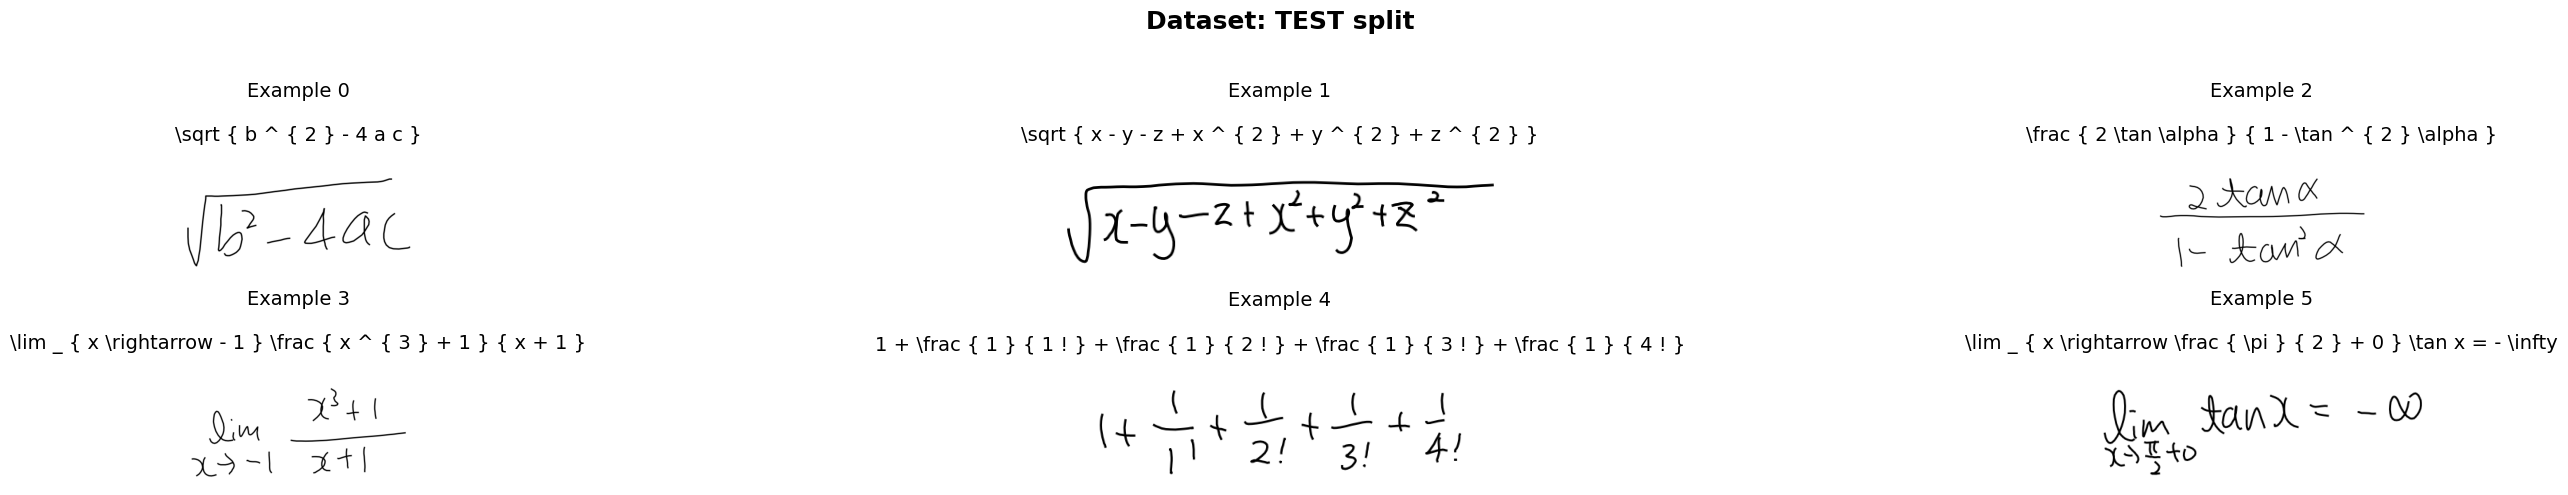

In [ ]:
show_examples(dataset, "test", n=6, cols=3)


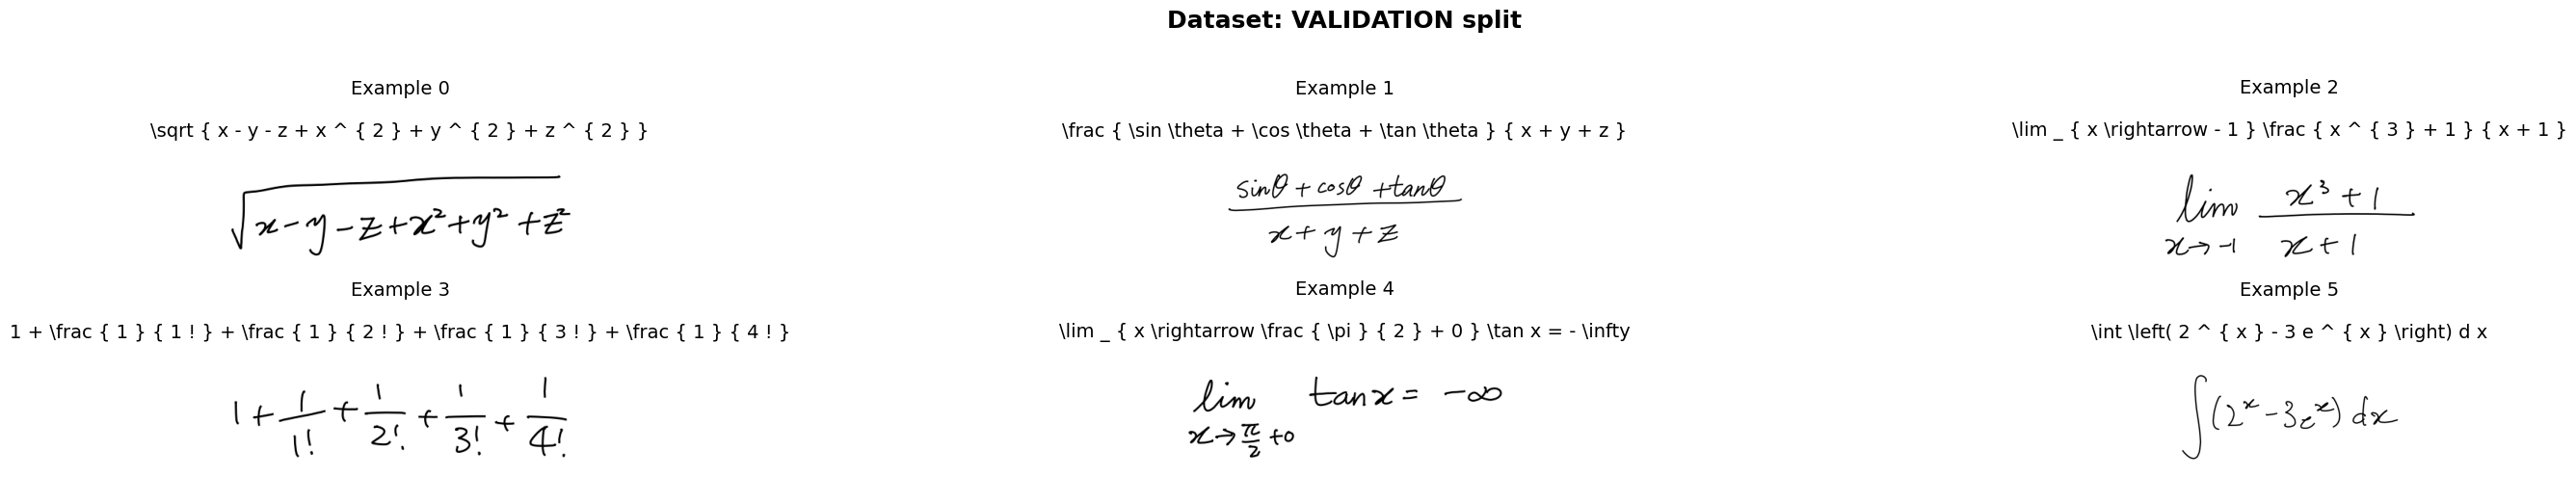

In [ ]:
show_examples(dataset, "validation", n=6, cols=3)


- **Content:** Diverse — ranging from simple equations to complex expressions; includes numeric-only, variable-only, and mixed examples, as well as various mathematical functions.
- **Image quality:** Generally clear, though some samples exhibit handwriting that is difficult to read, which may complicate recognition.
- **Special symbols:** Includes `\frac`, `\infty`, `\rightarrow`, etc.


**Dataset Overview: Summary**

The dataset consists of 1,200 training, 68 validation, and 70 test examples (≈90/5/5 split). Each example contains an RGBA image and a tokenized LaTeX string. No missing values or empty images were found. Pixel-level duplicate images (36 groups) were detected and removed from the training set. Duplicates within splits are intentional handwriting variations. Cross-split overlaps (23 unique texts) were identified but retained, as they represent different visual inputs and contribute valuable diversity to the training process. The content is diverse, with generally clear handwriting and special LaTeX symbols present. The dataset is now ready for statistical analysis and model fine-tuning. The total training set of ~1,164 examples (after deduplication) is small compared to large-scale benchmarks with over 1 million expressions. This motivates the use of parameter-efficient fine-tuning methods such as LoRA (Hu et al., 2022) to reduce the computational cost and memory footprint, as well as the inclusion of supplementary data from the larger MathWriting-human dataset (Gervais et al., 2024) to improve generalization.


#### 1.1.2. Statistical Analysis of Images and Texts


To better understand the data distribution, we perform a statistical analysis of image dimensions and text lengths across all three splits. This helps us assess the variability in the data and identify any inconsistencies between the splits.


In [ ]:
# Collect all data
split_data_raw = {}
split_labels = []

for split_name in dataset.keys():
    split_data = dataset[split_name]
    split_labels.append(split_name)

    sizes = [img.size for img in split_data["image"]]
    widths = [w for w, h in sizes]
    heights = [h for w, h in sizes]

    text_field = "text"
    lengths = [len(ex[text_field]) for ex in split_data]
    tokens = [ex[text_field].split() for ex in split_data]
    token_counts = [len(t) for t in tokens]
    all_tokens = [t for seq in tokens for t in seq]

    split_data_raw[split_name] = {
        "sizes": sizes,
        "widths": widths,
        "heights": heights,
        "lengths": lengths,
        "token_counts": token_counts,
        "all_tokens": all_tokens,
        "n": len(split_data),
        "example": split_data[0],
        "text_field": text_field
    }

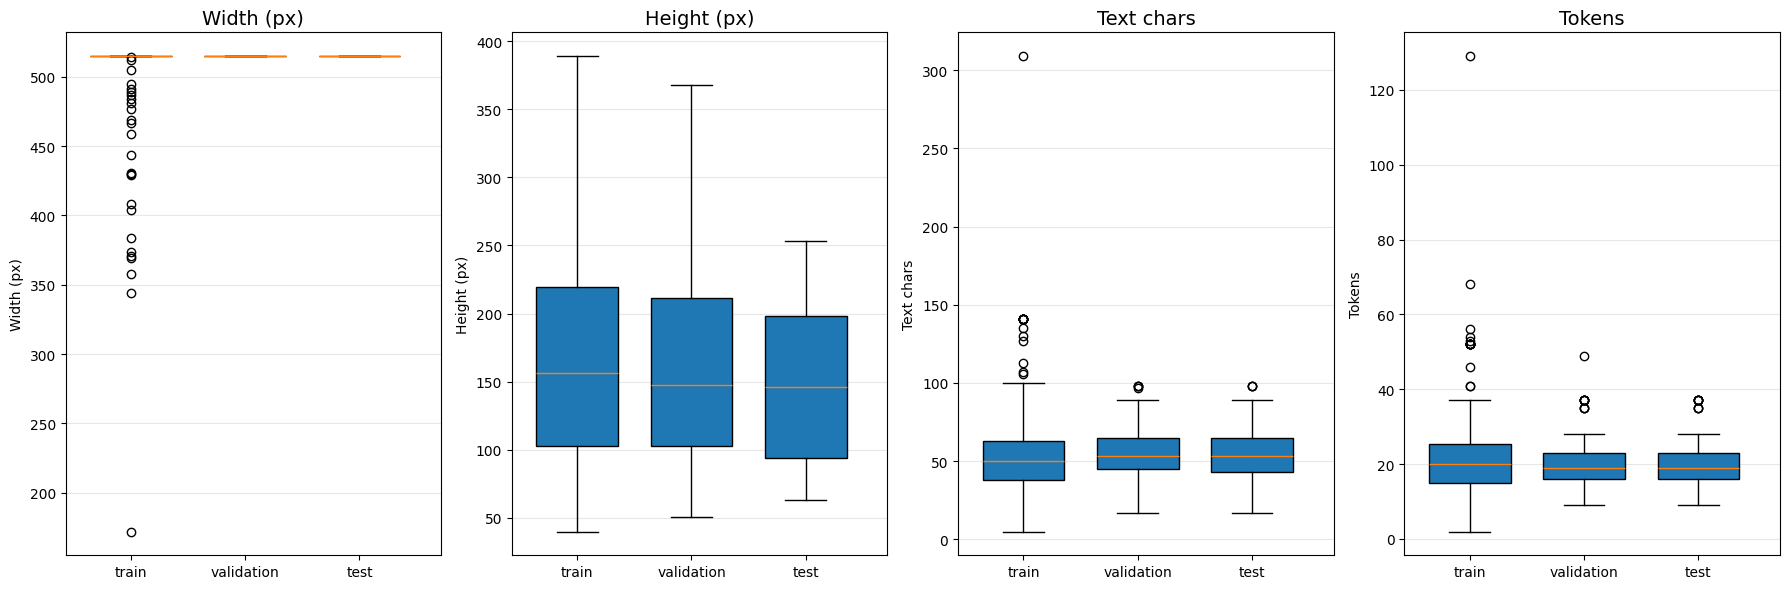

In [ ]:
# Box plots
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for ax, (name, vals) in zip(axes, {
    "Width (px)": [split_data_raw[s]["widths"] for s in split_labels],
    "Height (px)": [split_data_raw[s]["heights"] for s in split_labels],
    "Text chars": [split_data_raw[s]["lengths"] for s in split_labels],
    "Tokens": [split_data_raw[s]["token_counts"] for s in split_labels]
}.items()):
    bp = ax.boxplot(vals, positions=[0,0.7,1.4], tick_labels=split_labels, patch_artist=True, widths=0.5)
    ax.set_title(name, fontsize=14)
    ax.set_ylabel(name)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(-0.4, 1.9)

plt.tight_layout()
plt.show()

The box plots reveal the following insights:

- **Image width:** The width is highly consistent across splits, with most images around 515 pixels. There is a small number of outliers with smaller widths in the training set.

- **Image height:** The height shows more variability, ranging from approximately 40 to 390 pixels. The distributions are similar across splits, though the test set has slightly lower values on average.

- **Text length (characters):** The length of LaTeX strings is relatively consistent across all splits, with most examples falling between 20 and 100 characters. The distributions are well-aligned, confirming that the splits are representative of each other.

- **Token count:** The number of tokens per sequence is also consistent, with most sequences containing between 10 and 30 tokens. This indicates that the complexity of formulas is similar across splits.

Overall, the box plots confirm that the validation and test splits are representative of the training distribution, which supports the reliability of future evaluation.

We also compute summary statistics for each parameter. The table below provides a detailed overview:


In [ ]:
# DataFrame with statistics
rows = []

for split_name in split_labels:
    raw = split_data_raw[split_name]
    texts_in_split = [ex["text"] for ex in dataset[split_name]]

    rows.append({
        ("", "examples"): raw["n"],
        ("", "unique_texts"): len(set(texts_in_split)),
        ("Width (px)", "min"): min(raw["widths"]),
        ("Width (px)", "max"): max(raw["widths"]),
        ("Width (px)", "mean"): round(np.mean(raw["widths"]), 1),
        ("Width (px)", "median"): round(np.median(raw["widths"]), 1),
        ("Height (px)", "min"): min(raw["heights"]),
        ("Height (px)", "max"): max(raw["heights"]),
        ("Height (px)", "mean"): round(np.mean(raw["heights"]), 1),
        ("Height (px)", "median"): round(np.median(raw["heights"]), 1),
        ("Text chars", "min"): min(raw["lengths"]),
        ("Text chars", "max"): max(raw["lengths"]),
        ("Text chars", "mean"): round(np.mean(raw["lengths"]), 1),
        ("Text chars", "median"): round(np.median(raw["lengths"]), 1),
        ("Tokens", "min"): min(raw["token_counts"]),
        ("Tokens", "max"): max(raw["token_counts"]),
        ("Tokens", "mean"): round(np.mean(raw["token_counts"]), 1),
        ("Tokens", "median"): round(np.median(raw["token_counts"]), 1),
        ("Tokens", "unique"): len(set(raw["all_tokens"]))
    })

columns = pd.MultiIndex.from_tuples(rows[0].keys())
df_info = pd.DataFrame([dict(r) for r in rows], index=split_labels, columns=columns)
df_info

Width (px)                    Height (px)  \
           examples unique_texts        min  max   mean median         min   
train          1164          291        172  515  513.2  515.0          40   
validation       68           26        515  515  515.0  515.0          51   
test             70           23        515  515  515.0  515.0          63   

                              Text chars                   Tokens             \
            max   mean median        min  max  mean median    min  max  mean   
train       389  169.3  156.0          5  309  51.0   50.0      2  129  20.6   
validation  368  164.0  147.5         17   98  55.4   53.5      9   49  20.9   
test        253  147.1  146.0         17   98  53.7   53.0      9   37  20.3   

                          
           median unique  
train        20.0     83  
validation   19.0     54  
test         19.0     49

**Statistical Analysis: Summary**

Image widths are stable (~ 515 px), while heights vary (40–389 px). Unique text counts per split are reported in the table above. Text lengths average 51–55 characters (~ 21 tokens) across splits, with max 309 chars in training and 98 in val/test. Unique token vocabulary ranges from 49 to 83 tokens across splits. The distributions are consistent, confirming that the splits are well-balanced.

#### 1.1.3. Subsection summary


The `linxy/LaTeX_OCR` (`human_handwrite`) dataset provides 1,200 training, 68 validation, and 70 test examples. Key findings:

- **Data quality:** No missing values or empty images. Thirty-six pixel-level duplicate image groups were detected and removed from the training set (see Section 1.1.1). Duplicate texts within splits are intentional — multiple handwriting styles for the same formula. Twenty-three unique texts appear across all three splits but with visually distinct handwriting, so they are retained as valid training signal to preserve data diversity.

- **Image properties:** RGBA PNG images with consistent width (~515 px) and variable height (40–389 px). Conversion to RGB will be required during dataset preparation, as most VLMs expect 3-channel input.

- **Text properties:** Space-tokenized LaTeX strings averaging 21 tokens per sequence, with 291 unique formulas in training (see the table above for per-split counts) and a vocabulary of 49–83 unique tokens across splits. Formula complexity ranges from simple numeric expressions to multi-level fractions, integrals, and logical symbols.

- **Implications for training:** The small dataset size (1,200 examples) makes overfitting a concern. Our regularization strategy is threefold: (1) LoRA freezes the base model and trains only low-rank adapters; (2) lora_dropout=0.1 adds stochastic regularization; (3) checkpoint selection on the validation set prevents over-training. The balanced distributions across splits ensure that evaluation metrics will be reliable and representative.

- **Practical next steps:** Based on the observed image properties, we will resize and pad images to a fixed resolution during preprocessing, and convert RGBA images to RGB format to ensure compatibility with the chosen Vision-Language Model architecture.


### 1.2. deepcopy/MathWriting-human


The second dataset, [deepcopy/MathWriting-human](https://huggingface.co/datasets/deepcopy/MathWriting-human), contains human-written mathematical expressions. The dataset has its own train/val/test splits, but only the training split will be used — as a supplement to LaTeX_OCR in combined SFT. Validation and test evaluation always uses LaTeX_OCR's splits. We analyze the structure, quality, and compatibility of a subsample from this dataset.


In [ ]:
dataset_mw = load_dataset("deepcopy/MathWriting-human")

README.md:   0%|          | 0.00/3.27k [00:00<?, ?B/s]

data/train-00000-of-00003-ab0ae6b9fa4a3f(…): reconstructing file:   0%|          |  0.00B /  373MB            

data/train-00000-of-00003-ab0ae6b9fa4a3f(…): downloading bytes:           |  0.00B            

data/train-00001-of-00003-589d2b65116e09(…): reconstructing file:   0%|          |  0.00B /  374MB            

data/train-00001-of-00003-589d2b65116e09(…): downloading bytes:           |  0.00B            

...

data/val-00000-of-00001-184984e66f80ed7a(…): reconstructing file:   0%|          |  0.00B / 81.6MB            

data/val-00000-of-00001-184984e66f80ed7a(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/229864 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7644 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/15674 [00:00<?, ? examples/s]

In [ ]:
dataset_mw


DatasetDict({
    train: Dataset({
        features: ['image', 'latex', 'sample_id', 'split_tag', 'data_type'],
        num_rows: 229864
    })
    test: Dataset({
        features: ['image', 'latex', 'sample_id', 'split_tag', 'data_type'],
        num_rows: 7644
    })
    val: Dataset({
        features: ['image', 'latex', 'sample_id', 'split_tag', 'data_type'],
        num_rows: 15674
    })
})

The dataset contains 229,864 training, 15,674 validation, and 7,644 test examples. Note that only the training split will be used in Supervised Fine-Tuning — validation and test evaluation remains on the LaTeX_OCR splits. The MathWriting-human dataset was introduced by Gervais et al. (2024) as part of a benchmark for handwritten mathematical expression recognition.


For fine-tuning, we use a subset of 5,000 examples from MathWriting, combined with the LaTeX_OCR training split (~ 1,164 examples after duplicate removal), resulting in approximately 6,164 training examples. This subset size was chosen as a practical trade-off: it provides sufficient diversity for fine-tuning while keeping the total training time within the free Colab GPU limits. Prior work on data augmentation for Image-to-LaTeX (Orji et al., 2023) has shown that supplementary training data from diverse sources improves generalization, especially for small primary datasets. With an effective batch size of 16, this results in approximately 385 optimization steps per epoch. Based on our preliminary runs on a T4 GPU, each step takes approximately 5–8 seconds. Therefore, one epoch takes ~ 30–50 minutes, and 3 epochs require ~ 1.5–2.5 hours — well within the free Colab time limit (~ 5 hours), leaving ample margin for checkpoint evaluation and debugging.

In [ ]:
mw_train_subsample = dataset_mw["train"].shuffle(seed=RANDOM_STATE).select(range(MW_SUBSAMPLE_SIZE))


Let us examine the structure of a single example.


In [ ]:
ex_mw = mw_train_subsample[0]
print("TRAIN split:")
for key, value in ex_mw.items():
    if key == "image":
        print(f"  {key}: {type(value).__name__}, size={value.size}, mode={value.mode}")
    else:
        print(f"  {key}: {type(value).__name__} = {repr(value)[:100]}")

TRAIN split:
  image: JpegImageFile, size=(316, 73), mode=RGB
  latex: str = '\\Delta x_{meas}(t_{j+1})'
  sample_id: str = '964e79acf7f65fb0'
  split_tag: str = 'train'
  data_type: str = 'human'


Key differences from LaTeX_OCR: (1) the text field is named latex instead of text, which requires renaming before use; (2) an image is already in RGB mode (RGBA→RGB conversion probably isn't needed); (3) each example includes additional metadata columns (sample_id, split_tag, data_type) that are not needed for training.


#### 1.2.1. Quality Checks


In [ ]:
mw_train = mw_train_subsample
n = len(mw_train)


In [ ]:
mw_texts = []
modes = []

for ex in tqdm(mw_train, desc="Loading texts", total=n):
    mw_texts.append(ex["latex"])
    modes.append(ex["image"].mode)

print(f"Total examples: {n}")
print(f"Missing text:   {sum(1 for t in mw_texts if not t)}")
print(f"Unique texts:   {len(set(mw_texts))} ({len(set(mw_texts))/n:.1%})")
print(f"Duplicate texts: {n - len(set(mw_texts))} ({(n - len(set(mw_texts)))/n:.1%})")
print(f"Image modes (first {n}): {Counter(modes).most_common()}")


Loading texts: 100%|██████████| 5000/5000 [00:03<00:00, 1467.55it/s]

Total examples: 5000
Missing text:   0
Unique texts:   4208 (84.2%)
Duplicate texts: 792 (15.8%)
Image modes (first 5000): [('RGB', 5000)]


All images are in RGB mode — no conversion is needed. About 16% of texts are duplicates. No missing values were found.


#### 1.2.2. Duplicate Analysis


We check for pixel-level duplicates in the 5,000-example subsample. Text-level duplication is analyzed separately below.


In [ ]:
# Check for pixel-level duplicate images (on subsample — full dataset is too large)
print("Checking for duplicate images in MathWriting subsample...")
mw_hashes = set()
mw_img_dups = 0
for ex in tqdm(mw_train, desc="Loading texts", total=n):
    h = md5(ex["image"].tobytes()).hexdigest()
    if h in mw_hashes:
        mw_img_dups += 1
    mw_hashes.add(h)

print(f"Subsample size: {len(mw_train_subsample)}")
print(f"Pixel-level duplicate images: {mw_img_dups}")

Checking for duplicate images in MathWriting subsample...


Loading texts: 100%|██████████| 5000/5000 [00:04<00:00, 1086.20it/s]

Subsample size: 5000
Pixel-level duplicate images: 0


In [ ]:
mw_text_counts = Counter(mw_texts)
most_common_mw = mw_text_counts.most_common(1)[0]
print(f"Most common LaTeX: {repr(most_common_mw[0][:100])}")
print(f"Occurrences: {most_common_mw[1]}")

# Distribution of duplication frequency
dup_counts = [count for _, count in mw_text_counts.most_common(20)]
print(f"\nTop-20 most frequent formulas appear {dup_counts} times respectively")

Most common LaTeX: '(\\begin{matrix}n\\\\ k\\end{matrix})'
Occurrences: 5

Top-20 most frequent formulas appear [5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4] times respectively


The top-20 duplication frequencies range from 4 to 5, showing a relatively even spread across different formulas rather than concentration on a single template.


#### 1.2.3. LaTeX Format Comparison


A notable difference between the two datasets is the LaTeX formatting style. LaTeX_OCR uses space-tokenized LaTeX (spaces around braces and operators, e.g., `\frac { a } { b }`), while MathWriting-human predominantly uses compact LaTeX (e.g., `\frac{a}{b}`). Both formats are valid LaTeX and render identically. We do not modify the format of either dataset — the normalized exact match metric (`EM_norm`, which strips all spaces before comparison) ensures fair evaluation regardless of which format the model outputs.


In [ ]:
# Compare formats side by side
print("=== LaTeX_OCR (space-tokenized) ===")
for i in range(3):
    print(f"  {dataset['train'][i]['text']}")

print("\n=== MathWriting-human (compact) ===")
for i in range(3):
    print(f"  {mw_train[i]['latex']}")

# Quantify the difference
mw_with_spaces = sum(1 for t in mw_texts if ' ' in t.strip())
ocr_with_spaces = sum(1 for t in [ex["text"] for ex in dataset["train"]] if ' ' in t.strip())

print(f"\nTexts with internal spaces:")
print(f"  LaTeX_OCR:         {ocr_with_spaces}/{len(dataset['train'])} "
      f"({ocr_with_spaces/len(dataset['train']):.0%})")
print(f"  MathWriting-human: {mw_with_spaces}/{n} "
      f"({mw_with_spaces/n:.0%})")

=== LaTeX_OCR (space-tokenized) ===
  z _ { 1 } = r _ { 1 } ( \cos \theta _ { 1 } + i \sin \theta _ { 1 } )
  \log z = \log r + i ( \theta + 2 n \pi )
  2 1 - 5 \sqrt { 2 1 } + ( 1 5 \sqrt { 7 } - 2 1 \sqrt { 3 } ) i

=== MathWriting-human (compact) ===
  \Delta x_{meas}(t_{j+1})
  \omega_{1}=\frac{L_{1}}{mr^{2}}
  (\begin{matrix}n\\ n/2\end{matrix})

Texts with internal spaces:
  LaTeX_OCR:         1164/1164 (100%)
  MathWriting-human: 1271/5000 (25%)


In [ ]:
# Show examples WITH spaces from MathWriting
mw_with_space = [(i, t) for i, t in enumerate(mw_texts) if " " in t.strip()]

random.seed(RANDOM_STATE)
samples = random.sample(mw_with_space, min(10, len(mw_with_space)))

print(f"\nExamples with spaces ({len(mw_with_space)}/{len(mw_train)} = "
      f"{len(mw_with_space)/len(mw_train):.1%}):\n")
for idx, text in samples:
    print(f"  [{idx}] {repr(text[:120])}")


Examples with spaces (1271/5000 = 25.4%):

  [947] '[\\begin{matrix}r\\\\ 0\\\\ c\\end{matrix}]'
  [236] 'y\\notin FV(N)'
  [2319] '\\{\\begin{matrix}3\\\\ 8\\end{matrix}\\}'
  [2047] '\\frac{\\partial}{\\partial t}\\langle\\frac{\\partial f}{\\partial t},\\frac{\\partial f}{\\partial s}\\rangle=0'
  [1886] '(\\begin{matrix}0&a\\\\ -a&0\\end{matrix})'
  [1174] '(\\begin{matrix}4\\\\ 2\\end{matrix})=6'
  [883] 'l_{c}=\\frac{kT_{s}}{\\pi d^{2}p_{s}}'
  [4388] '\\int cose^{x}dx'
  [743] '(\\begin{matrix}n+1\\\\ 3\\end{matrix})+1'
  [4773] 'A=[\\begin{matrix}2&1\\\\ 1&2\\end{matrix}]'


The comparison confirms a format difference: virtually all LaTeX_OCR examples contain spaces between tokens (`\frac { a } { b }`), while ~75% of MathWriting-human examples use compact notation (`\frac{a}{b}`). The remaining ~25% of MathWriting examples contain legitimate LaTeX spaces (e.g., `x + y`, `\int ds`, `matrix separators`), which are part of standard LaTeX notation. When combining datasets in SFT, the model will encounter both formats. Since evaluation uses normalized exact match (spaces stripped), this format discrepancy does not affect metric computation.


#### 1.2.4. Sample Visualizations


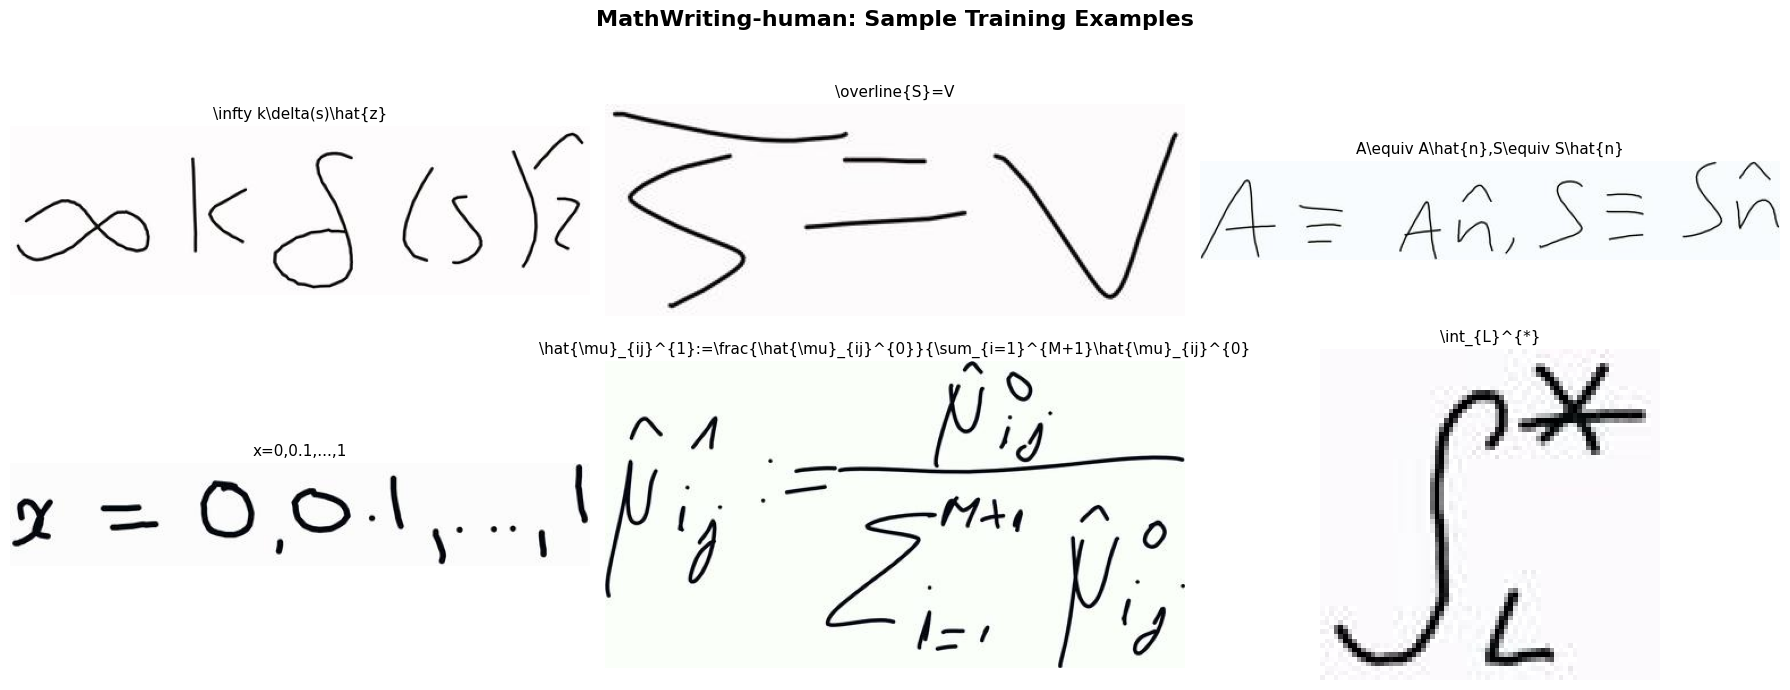

In [ ]:
random.seed(RANDOM_STATE)
sample_idxs = random.sample(range(len(mw_train)), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 7))
axes = axes.flatten()

for ax, idx in zip(axes, sample_idxs):
    ex = mw_train[idx]
    ax.imshow(ex["image"])
    ax.set_title(f"{ex['latex'][:80]}", fontsize=11)
    ax.axis("off")

fig.suptitle("MathWriting-human: Sample Training Examples", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

The handwriting styles in MathWriting-human are visually similar to LaTeX_OCR — both contain handwritten mathematical formulas on light-colored backgrounds. While LaTeX_OCR images consistently use a white background, MathWriting-human includes minor background color variations (off-white, light gray). As discussed in Orji et al. (2023), noise and background variation in input images can impact OCR accuracy; however, these minor differences are natural acquisition artifacts and do not require preprocessing — the VLM processor handles normalization during training. The image quality is generally good, with varying levels of neatness. Formula complexity ranges from simple expressions to complex nested structures.


#### 1.2.5. Statistical Analysis


The summary table below compares text and image statistics between the full 230K training set and the 5,000-example subsample to verify that the subsample is representative. Text statistics are computed exactly; image dimensions are sampled (1,000 images).


In [ ]:
# Summary table: full dataset (230K) vs 5,000-example subsample

# Full dataset statistics
print("Computing statistics on full training set (230K)...")
full_lengths = []
full_token_counts = []
full_unique = set()
for ex in tqdm(dataset_mw["train"], desc="Full dataset"):
    t = ex["latex"]
    full_unique.add(t)
    full_lengths.append(len(t))
    full_token_counts.append(len(t.split()))

# Image dimensions: sample 1,000 from full dataset
random.seed(RANDOM_STATE)
full_img_idxs = random.sample(range(len(dataset_mw["train"])), 1000)
full_widths = [dataset_mw["train"][i]["image"].size[0] for i in full_img_idxs]
full_heights = [dataset_mw["train"][i]["image"].size[1] for i in full_img_idxs]

# Subsample statistics
sub_lengths = [len(t) for t in mw_texts]
sub_token_counts = [len(t.split()) for t in mw_texts]

# Image dimensions: sample 1,000 from subsample
random.seed(RANDOM_STATE)
sub_img_idxs = random.sample(range(len(mw_train)), 1000)
sub_widths = [mw_train[i]["image"].size[0] for i in sub_img_idxs]
sub_heights = [mw_train[i]["image"].size[1] for i in sub_img_idxs]

# Build table
mw_data = {
    ("", "examples"):          [len(dataset_mw["train"]), n],
    ("", "unique_texts"):      [len(full_unique), len(set(mw_texts))],
    ("Width (px)", "min"):     [min(full_widths), min(sub_widths)],
    ("Width (px)", "max"):     [max(full_widths), max(sub_widths)],
    ("Width (px)", "mean"):    [round(np.mean(full_widths), 1), round(np.mean(sub_widths), 1)],
    ("Width (px)", "median"):  [round(np.median(full_widths), 1), round(np.median(sub_widths), 1)],
    ("Height (px)", "min"):    [min(full_heights), min(sub_heights)],
    ("Height (px)", "max"):    [max(full_heights), max(sub_heights)],
    ("Height (px)", "mean"):   [round(np.mean(full_heights), 1), round(np.mean(sub_heights), 1)],
    ("Height (px)", "median"): [round(np.median(full_heights), 1), round(np.median(sub_heights), 1)],
    ("Text chars", "min"):     [min(full_lengths), min(sub_lengths)],
    ("Text chars", "max"):     [max(full_lengths), max(sub_lengths)],
    ("Text chars", "mean"):    [round(np.mean(full_lengths), 1), round(np.mean(sub_lengths), 1)],
    ("Text chars", "median"):  [round(np.median(full_lengths), 1), round(np.median(sub_lengths), 1)],
    ("Tokens", "min"):         [min(full_token_counts), min(sub_token_counts)],
    ("Tokens", "max"):         [max(full_token_counts), max(sub_token_counts)],
    ("Tokens", "mean"):        [round(np.mean(full_token_counts), 1), round(np.mean(sub_token_counts), 1)],
    ("Tokens", "median"):      [round(np.median(full_token_counts), 1), round(np.median(sub_token_counts), 1)],
}

df_mw = pd.DataFrame(mw_data,
                     index=["train (full, 229K)", "train (subsample, 5K)"],
                     columns=pd.MultiIndex.from_tuples(mw_data.keys()))
df_mw

Computing statistics on full training set (230K)...


Full dataset: 100%|██████████| 229864/229864 [01:45<00:00, 2184.90it/s]


Width (px)                     \
                      examples unique_texts        min  max   mean median   
train (full, 229K)      229864        52995         21  512  311.2  297.0   
train (subsample, 5K)     5000         4208         35  512  312.3  302.0   

                      Height (px)                    Text chars             \
                              min  max   mean median        min  max  mean   
train (full, 229K)             27  512  148.0  139.0          1  188  27.8   
train (subsample, 5K)          29  512  147.5  134.0          1  136  27.6   

                             Tokens                  
                      median    min max mean median  
train (full, 229K)      25.0      1  10  1.3    1.0  
train (subsample, 5K)   25.0      1   7  1.3    1.0

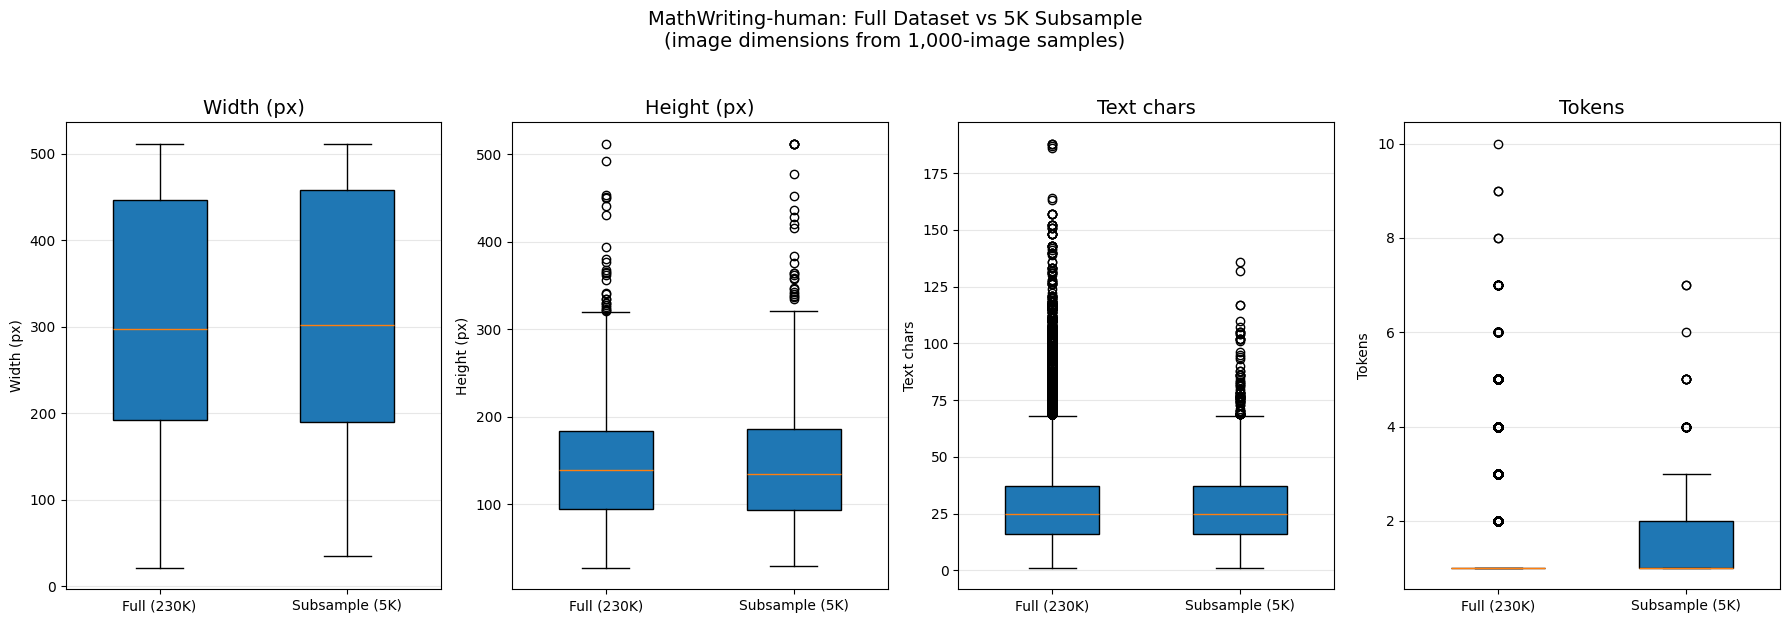

In [ ]:
# Box plots: full dataset (230K) vs subsample (5K)
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

labels = ["Full (230K)", "Subsample (5K)"]

for ax, (name, vals) in zip(axes, {
    "Width (px)":   [full_widths, sub_widths],
    "Height (px)":  [full_heights, sub_heights],
    "Text chars":   [full_lengths, sub_lengths],
    "Tokens":       [full_token_counts, sub_token_counts],
}.items()):
    ax.boxplot(vals, tick_labels=labels, patch_artist=True, widths=0.5)
    ax.set_title(name, fontsize=14)
    ax.set_ylabel(name)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle("MathWriting-human: Full Dataset vs 5K Subsample\n"
             "(image dimensions from 1,000-image samples)", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

The summary table and box plots confirm that the 5,000-example subsample is representative of the full 230K dataset. Text length distributions are nearly identical: mean character count differs by only 0.2 (27.8 vs 27.6), and median values match exactly for both characters (25) and tokens (1.0). Image dimensions show the same pattern — mean width and height differ by less than 0.5%. The box plots further illustrate that the interquartile ranges and medians align closely across all four metrics.

The only notable differences are in the extreme values: the full dataset contains formulas up to 188 characters and 10 tokens, while the subsample caps at 136 characters and 7 tokens. These are tail-of-distribution edge cases that a random 5K sample is unlikely to capture, and they do not affect the subsample's representativeness for training purposes. The unique text count is proportionally higher in the subsample (84% vs 23%), which is expected — with fewer total examples, each formula is less likely to be drawn multiple times, but the underlying formula distribution remains the same.


#### 1.2.6. MathWriting-human: Summary


The full dataset provides 229,864 training examples. The 5,000-example subsample used for SFT has RGB images (mean ~ 312×148 px) and compact LaTeX annotations (mean 28 chars, 1.3 tokens). No pixel-level duplicate images were found (checked on the 5,000-subsample). About 16% of texts are duplicates — the top-20 most frequent formulas appear 4–5 times each, indicating a spread across different common formulas rather than concentration on a single template. ~ 75% of examples use compact LaTeX; the remaining ~ 25% contain legitimate spaces within formulas (e.g., `x + y`, `\int ds`, matrix & separators). The subsample was verified to be representative of the full dataset: mean text lengths and image dimensions differ by less than 1%, confirming that training on the subsample will expose the model to the same data distribution.


### 1.3. Cross-Dataset Comparison


Before combining the datasets for Supervised Fine-Tuning, we compare their properties to identify potential compatibility issues and determine the preprocessing steps required.


In [ ]:
# Compute comparison table from already-collected data

ocr_texts = [ex["text"] for ex in dataset["train"]]
ocr_unique = len(set(ocr_texts))
mw_unique = len(set(mw_texts))

# LaTeX_OCR image stats
ocr_widths = split_data_raw["train"]["widths"]
ocr_heights = split_data_raw["train"]["heights"]

comparison = {
    ("", "Train size"): [f"{len(dataset['train']):,}",
                         f"{len(mw_train):,}"],
    ("", "Unique formulas"): [f"{ocr_unique:,}", f"{mw_unique:,}"],
    ("", "Text field"): ["text", "latex (rename to text)"],
    ("", "Image mode"): ["RGBA (PNG)", "RGB (JPG)"],
    ("LaTeX format", "Style"): [
        "Space-tokenized" if sum(1 for t in ocr_texts if " " in t.strip()) / len(ocr_texts) > 0.9 else "Mixed",
        "Compact" if sum(1 for t in mw_texts if " " in t.strip()) / len(mw_texts) < 0.3 else "Mixed",
    ],
    ("LaTeX format", "With spaces"): [
        f"{sum(1 for t in ocr_texts if ' ' in t.strip())/len(ocr_texts):.0%}",
        f"{sum(1 for t in mw_texts if ' ' in t.strip())/len(mw_texts):.0%}",
    ],
    ("Image dims", "Width (mean)"): [f"{np.mean(ocr_widths):.0f} px",
                                     f"{np.mean(sub_widths):.0f} px"],
    ("Image dims", "Height (mean)"): [f"{np.mean(ocr_heights):.0f} px",
                                      f"{np.mean(sub_heights):.0f} px"],
    ("Quality", "Missing values"): ["0", "0"],
    ("Quality", "Duplicate texts"): [
        f"{(len(ocr_texts) - ocr_unique)/len(ocr_texts):.0%}",
        f"{(len(mw_texts) - mw_unique)/len(mw_texts):.0%}",
    ],
}

df_comp = pd.DataFrame(comparison,
                       index=["linxy/LaTeX_OCR", "deepcopy/MathWriting-human"])
df_comp


\
                           Train size Unique formulas              Text field   
linxy/LaTeX_OCR                 1,164             291                    text   
deepcopy/MathWriting-human      5,000           4,208  latex (rename to text)   

                                           LaTeX format              \
                            Image mode            Style With spaces   
linxy/LaTeX_OCR             RGBA (PNG)  Space-tokenized        100%   
deepcopy/MathWriting-human   RGB (JPG)          Compact         25%   

                             Image dims                      Quality  \
                           Width (mean) Height (mean) Missing values   
linxy/LaTeX_OCR                  513 px        169 px              0   
deepcopy/MathWriting-human       312 px        148 px              0   

                                            
                           Duplicate texts  
linxy/LaTeX_OCR                        75%  
deepcopy/MathWriting-human             16%

The table reveals two structural differences between the datasets. First, LaTeX_OCR uses space-tokenized LaTeX (e.g., `\frac { a } { b }`) while MathWriting-human uses compact notation (e.g., `\frac{a}{b}`) — this is a formatting difference only, as both render identically. Second, MathWriting-human contains significantly more unique formulas relative to its size: 4,208 unique texts in 5,000 examples (84%) compared to 291 unique texts in 1,164 examples (25%) for LaTeX_OCR. The remaining parameters — image dimensions, missing values, duplicate rate — are compatible and require no special handling beyond the column rename noted above. Text length and token count distributions are compared visually below.


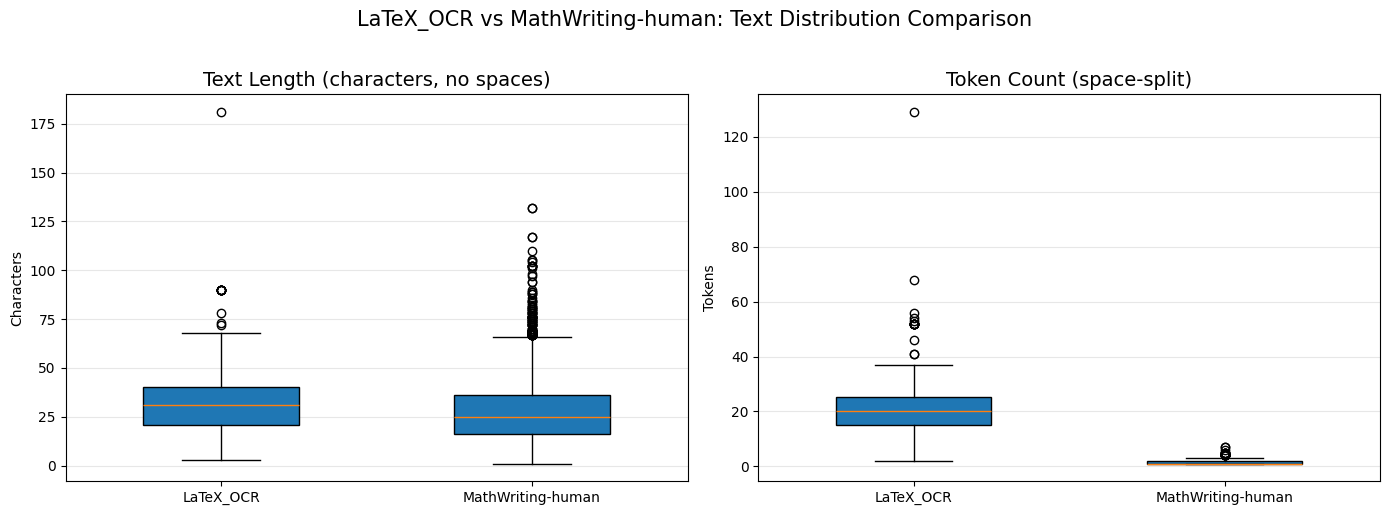

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length (characters, spaces removed for fair comparison)
axes[0].boxplot(
    [[len(t.replace(" ", "")) for t in ocr_texts],
     [len(t.replace(" ", "")) for t in mw_texts]],
    tick_labels=["LaTeX_OCR", "MathWriting-human"],
    patch_artist=True, widths=0.5
)
axes[0].set_title("Text Length (characters, no spaces)", fontsize=14)
axes[0].set_ylabel("Characters")
axes[0].grid(axis='y', alpha=0.3)

# Token count (space-split)
axes[1].boxplot(
    [[len(t.split()) for t in ocr_texts],
     [len(t.split()) for t in mw_texts]],
    tick_labels=["LaTeX_OCR", "MathWriting-human"],
    patch_artist=True, widths=0.5
)
axes[1].set_title("Token Count (space-split)", fontsize=14)
axes[1].set_ylabel("Tokens")
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle("LaTeX_OCR vs MathWriting-human: Text Distribution Comparison",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


After removing spaces, LaTeX_OCR formulas are on average longer than MathWriting-human formulas, with a higher median. This reflects LaTeX_OCR's inclusion of more structurally complex expressions (multi-level fractions, integrals, multi-variable equations). The token count plot shows a pronounced gap that is largely a formatting artifact: space-tokenized LaTeX inflates token counts compared to compact notation, so the difference in tokens is greater than the difference in actual formula complexity.


#### 1.3.1. Key Findings


- **LaTeX format mismatch:** LaTeX_OCR uses space-tokenized LaTeX while MathWriting-human uses compact LaTeX. During training, the model will learn from both formats. Since we evaluate using normalized exact match (spaces stripped), this does not bias the metrics. However, the model's preferred output format may shift toward the majority style.
- **Formula complexity:** LaTeX_OCR contains more structurally complex formulas on average (multi-level fractions, integrals, multi-variable equations), while MathWriting-human formulas tend to be shorter and more uniform. Combining both datasets broadens the complexity spectrum available during training.
- **Image size difference:** MathWriting-human images are smaller in both dimensions: ~39% narrower (312 vs 515 px) and ~12% shorter (148 vs 169 px) than LaTeX_OCR. Both will be resized to the same resolution by the processor(longest_edge=512), so this is handled automatically during preprocessing.
- **Scale imbalance:** MathWriting-human is ~ 198× larger. Using all 230K examples would overwhelm the 1,164 LaTeX_OCR examples. A subsample is needed to maintain a balanced influence from both datasets.
- **Field name difference:** MathWriting-human uses `latex` instead of `text`. Renaming is required before concatenation.
- **Image format:** LaTeX_OCR uses PNG (RGBA), MathWriting-human uses JPG (RGB). This does not affect training — the processor handles both formats, and the collate function converts all images to RGB.
- **Pixel-level duplicate images:** LaTeX_OCR contains 36 groups of pixel-identical images. All 36 groups have different but semantically equivalent LaTeX annotations (optional braces, whitespace differences). These were removed from the training set to eliminate label noise and cross-split data leakage. Test and validation remain unchanged. MathWriting-human has no pixel-level duplicates.


#### 1.3.2. Implications for Supervised Fine-Tuning (Combined Training)


Based on the comparison, the following preprocessing is required before combining the datasets for SFT:

- **Subsample MathWriting-human to 5,000 examples** (Gervais et al., 2024). The 5K subsample is shuffled with seed=42 to ensure reproducibility. The full dataset (230K) is ~ 198× larger than LaTeX_OCR. Using all of it would make training prohibitively long and dominate the loss signal. With 5,000 MathWriting + ~ 1,164 LaTeX_OCR (after duplicate removal) ≈ 6,164 total examples, the effective batch size is 16, yielding ~ 385 steps per epoch. On a T4 GPU, each step is expected to take approximately 5–8 seconds due to the multimodal nature of the model (vision + language). Thus, one epoch takes ~ 30–50 minutes, and 3 epochs require ~ 1.5–2.5 hours — well within the free Colab time limit (~ 5 hours), leaving ample margin for checkpoint evaluation and debugging.
- **Rename** the latex column to text for format consistency.
- **LaTeX format:** No format normalization is applied to either dataset. Both space-tokenized (LaTeX_OCR) and compact (MathWriting-human) LaTeX are valid and render identically. The evaluation metric (EM_norm) strips all spaces before comparison, so the model's output format does not affect scoring.
- **No image preprocessing** is needed beyond the standard RGB conversion and resizing already handled by the processor. MathWriting-human contains minor background color variations (off-white, light gray) compared to LaTeX_OCR's consistent white background, but these are natural acquisition differences that the VLM processor normalizes internally (see Section 1.2.4).

The combined dataset will use LaTeX_OCR's validation and test splits for evaluation, ensuring fair comparison with single-dataset SFT.


## 2. Evaluation Metrics

We evaluate model predictions using four metrics, organized at two complementary levels (string-level and character-level):

| Metric | Level | What it measures |
|--------|-------|------------------|
| **Exact Match (raw)** | String | % of predictions identical to reference |
| **Exact Match (normalized)** | String | Same, after removing spaces |
| **CER** | Character | Edit distance / reference length |
| **BLEU** | Corpus | N-gram overlap (sacrebleu) |

Normalization removes spaces because LaTeX_OCR uses space-tokenized LaTeX while MathWriting-human does not. This dual-level evaluation (string-level + character-level) follows the methodology advocated in the Image-to-LaTeX survey (Orji et al., 2023), which recommends combining exact match with character error rate for a more complete picture. CER is computed using the Wagner–Fischer dynamic programming algorithm (Wagner & Fischer, 1974), and BLEU follows the standard implementation (Papineni et al., 2002). Using normalized EM ensures fair comparison.

All four metrics are implemented in `metrics.py` (model-agnostic) and imported by both model notebooks, guaranteeing identical evaluation.

In [ ]:
# Metrics are defined in metrics.py
# let's verify they work correctly
test_preds = ["\\frac { a } { b }", "x + y", "c = d"]
test_refs  = ["\\frac { a } { b }", "x+y", "c = e"]
metrics = compute_metrics(test_preds, test_refs)
print(f"EM (raw):   {metrics['exact_match']:.1%}  (expected 33.3%)")
print(f"EM (norm.): {metrics['exact_match_normalized']:.1%}  (expected 66.7%)")
print(f"CER:        {metrics['cer']:.1%}  (expected 5.9%)")
print(f"BLEU:       {metrics['bleu']:.1f}  (expected 92.7)")

EM (raw):   33.3%  (expected 33.3%)
EM (norm.): 66.7%  (expected 66.7%)
CER:        5.9%  (expected 5.9%)
BLEU:       92.7  (expected 92.7)


Metrics are working as expected. The normalized EM (66.7%) is higher than raw EM (33.3%) because it ignores spacing differences ("x + y" vs "x+y").

## 3. One-Shot Example Selection

For one-shot inference, we select a single example from the training set to include in the prompt as a demonstration. The few-shot prompting paradigm was popularized by Brown et al. (2020), who showed that large language models can learn tasks from as few as one example in the prompt. For VLMs, a single demonstration is particularly valuable in domain-specific tasks such as handwritten formula recognition, where it primes the model to output LaTeX rather than natural language. Both model notebooks use the same index (ONE_SHOT_INDEX = 0) to ensure comparability.

> **Note:** The one-shot example is selected here (in EDA) for visual verification. Model notebooks reload the same example from the dataset using the same index.

One-shot example (index 0):
  LaTeX: z _ { 1 } = r _ { 1 } ( \cos \theta _ { 1 } + i \sin \theta _ { 1 } )


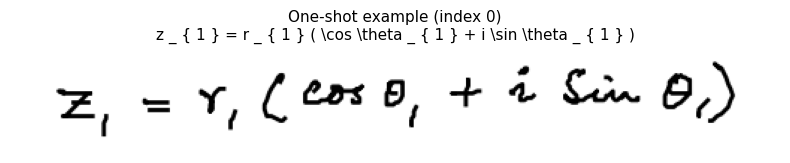

In [ ]:
# Select a one-shot example from the training set
ONE_SHOT_INDEX = 0
one_shot_example = dataset["train"][ONE_SHOT_INDEX]

print(f"One-shot example (index {ONE_SHOT_INDEX}):")
print(f"  LaTeX: {one_shot_example['text']}")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.imshow(one_shot_example["image"])
ax.set_title(f"One-shot example (index {ONE_SHOT_INDEX})\n{one_shot_example['text']}", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

The selected one-shot example is a medium-complexity formula containing subscripts, trigonometric functions, and fractions. It provides a representative demonstration of the handwriting-to-LaTeX conversion task.

## 4. Conclusion

This notebook established the data foundation and evaluation framework for the model comparison. Two datasets were analysed: `linxy/LaTeX_OCR` (1,164 training examples after pixel-level deduplication, 68 validation, 70 test) and a 5,000-example subsample of `deepcopy/MathWriting-human` (drawn from 229,864 training examples). Key findings from the EDA are summarised below.

**Data quality.** No missing values or empty images were found in either dataset. Thirty-six pixel-level duplicate groups were removed from the LaTeX_OCR training set — these carried different but semantically equivalent LaTeX annotations, introducing label noise that could confuse the model during fine-tuning. Twenty-three unique texts appear across all three LaTeX_OCR splits, but visual inspection confirmed these are different handwriting styles of the same formulas, so they were retained to preserve diversity. In the MathWriting subsample, ~16% of texts are duplicated (4–5 occurrences each, spread across different common formulas rather than concentrated on a single template), and no pixel-level duplicate images were detected.

**LaTeX format difference.** The two datasets use different formatting conventions: LaTeX_OCR uses space-tokenized LaTeX (e.g., `\frac { a } { b }`), while MathWriting-human predominantly uses compact notation (e.g., `\frac{a}{b}`). Both are valid and render identically. Since evaluation uses normalised exact match (spaces stripped before comparison), this difference does not bias the metrics. During combined SFT, the model learns from both formats simultaneously.

**Subsample representativeness.** The 5,000-example MathWriting subsample was verified to be representative of the full 230K dataset: mean text length differs by 0.2 characters (27.8 vs. 27.6), and image dimension distributions are nearly identical. This subsample size balances formula diversity with practical GPU training time on a free Colab T4.

**Implications for downstream notebooks.** The cleaned LaTeX_OCR training split and the 5,000-example MathWriting subsample form the combined training set (~6,164 examples) used in `2_smolvlm.ipynb` and `3_qwen3vl_*.ipynb`. Evaluation metrics (EM, EM normalised, CER, BLEU) are defined in `metrics.py` and imported by both model notebooks. The one-shot example selected in Section 3 is used for baseline inference in both model evaluations. All results are ultimately compared in `4_comparison.ipynb`.

## References

1. Orji E.Z., Haydar A., Erşan İ., Mwambe O.O. (2023). Advancing OCR Accuracy in Image-to-LaTeX Conversion—A Critical and Creative Exploration. *Applied Sciences*, 13(22), 12503. https://doi.org/10.3390/app132212503.

2. Hu E.J., Shen Y., Wallis P., Allen-Zhu Z., Li Y., Wang S., Wang L., Chen W. (2022). LoRA: Low-Rank Adaptation of Large Language Models. *ICLR 2022*. https://arxiv.org/abs/2106.09685.

3. Wagner R.A., Fischer M.J. (1974). The String-to-String Correction Problem. *Journal of the ACM*, 21(1), 168–173. https://doi.org/10.1145/321796.321811.

4.  Papineni K., Roukos S., Ward T., Zhu W.-J. (2002). BLEU: a Method for Automatic Evaluation of Machine Translation. *ACL 2002*. https://doi.org/10.3115/1073083.1073135.

5. Brown T.B., Mann B., Ryder N., et al. (2020). Language Models are Few-Shot Learners. *NeurIPS 2020*, 33, 1877–1901. https://arxiv.org/abs/2005.14165.

6. Lee K., Ippolito D., Nystrom A., et al. (2022). Deduplicating Training Data Makes Language Models Better. *TMLR 2022*. https://arxiv.org/abs/2107.06499.

7. linxy. (2024). linxy/LaTeX_OCR (Human Handwrite subset). HuggingFace Datasets. https://huggingface.co/datasets/linxy/LaTeX_OCR.

8. deepcopy. (2024). deepcopy/MathWriting-human. HuggingFace Datasets. https://huggingface.co/datasets/deepcopy/MathWriting-human.

9. Gervais, P., Fadeeva, A., et al. (2024). MathWriting: A Dataset for Handwritten Mathematical Expression Recognition. arXiv preprint. https://arxiv.org/abs/2404.10690.